<a href="https://colab.research.google.com/github/san031/Machine_learning-Artificial-Intelligence-Projects/blob/main/machine_learning/linear_regression/sales_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from datetime import datetime
import seaborn as sns
import plotly.express as px
import pandas as pd
import ast
import math
import random
from scipy.stats import skew
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import pickle

In [ ]:
store_df = pd.read_csv('/content/sample_data/Superstore.csv', encoding='latin1')
store_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
store_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
store_df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [ ]:
store_df.shape

(9994, 21)

In [ ]:
store_df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [ ]:
store_df['Ship Mode'].value_counts()

,count
Ship Mode,
Standard Class,5968
Second Class,1945
First Class,1538
Same Day,543


In [ ]:
store_df['Segment'].value_counts()

,count
Segment,
Consumer,5191
Corporate,3020
Home Office,1783


In [ ]:
store_df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


##STEP 2: PREPROCESSING(HANDLING MISSING VALUES)

In [ ]:
store_df['Ship Date'].unique()

array(['11/11/2016', '6/16/2016', '10/18/2015', ..., '5/23/2015',
       '1/23/2014', '3/3/2017'], dtype=object)

In [ ]:
store_df.nunique()

,0
Row ID,9994
Order ID,5009
Order Date,1237
Ship Date,1334
Ship Mode,4
Customer ID,793
Customer Name,793
Segment,3
Country,1
City,531


In [ ]:
store_df.unique()

AttributeError: 'DataFrame' object has no attribute 'unique'

In [ ]:
# store_df.isnull().sum()
store_df[store_df['Postal Code'].isnull()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [ ]:
print(store_df.duplicated().sum())

0


In [ ]:
store_df['Order Date'] = pd.to_datetime(store_df['Order Date'])
store_df['Ship Date'] = pd.to_datetime(store_df['Ship Date'])
print(store_df.dtypes)

Row ID                             int64
Order ID                          object
Order Date                datetime64[ns]
Ship Date                 datetime64[ns]
Ship Mode                         object
Customer ID                       object
Customer Name                     object
Segment                           object
Country                           object
City                              object
State                             object
Postal Code                        int64
Region                            object
Product ID                        object
Category                          object
Sub-Category                      object
Product Name                      object
Sales                            float64
Quantity                           int64
Discount                         float64
Profit                           float64
Order Month                        int32
Order Year                         int32
Order Quarter                      int32
Order Weekday   

In [ ]:
store_df.describe().apply(lambda x: round(x, 2))

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.00,9994,9994,9994.00,9994.00,9994.00,9994.00,9994.00
mean,4997.50,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.38,229.86,3.79,0.16,28.66
min,1.00,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.00,0.44,1.00,0.00,-6599.98
25%,2499.25,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.00,17.28,2.00,0.00,1.73
50%,4997.50,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.50,54.49,3.00,0.20,8.67
75%,7495.75,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.00,209.94,5.00,0.20,29.36
max,9994.00,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.00,22638.48,14.00,0.80,8399.98
std,2885.16,NaN,NaN,32063.69,623.25,2.23,0.21,234.26


In [ ]:
##Data visualization, storytelling  experimenting with charts : understanding the relationship b/w variables

Text(0.5, 1.0, 'Plot between Sales and categoty')

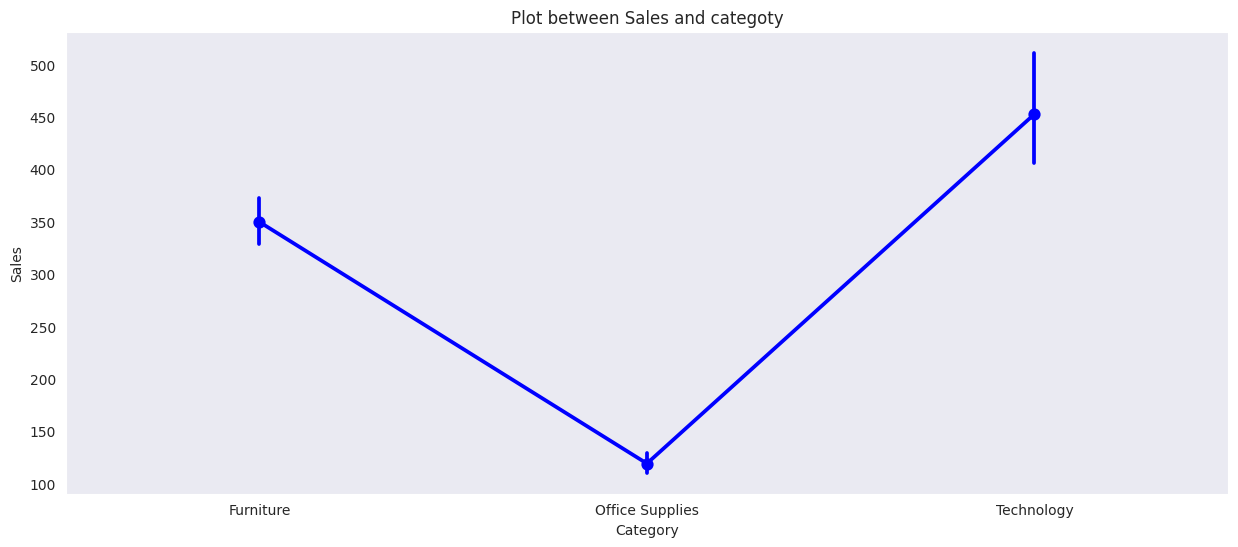

In [ ]:
plt.figure(figsize=(15,6))
sns.pointplot(x ="Category", y= "Sales", data = store_df, color = "blue")
sns.set_style("dark")
plt.title('Plot between Sales and category')

##The sales of furniture and Sales is skyrocketting, whereas office supplies is negligible

<Axes: xlabel='Sales', ylabel='Profit'>

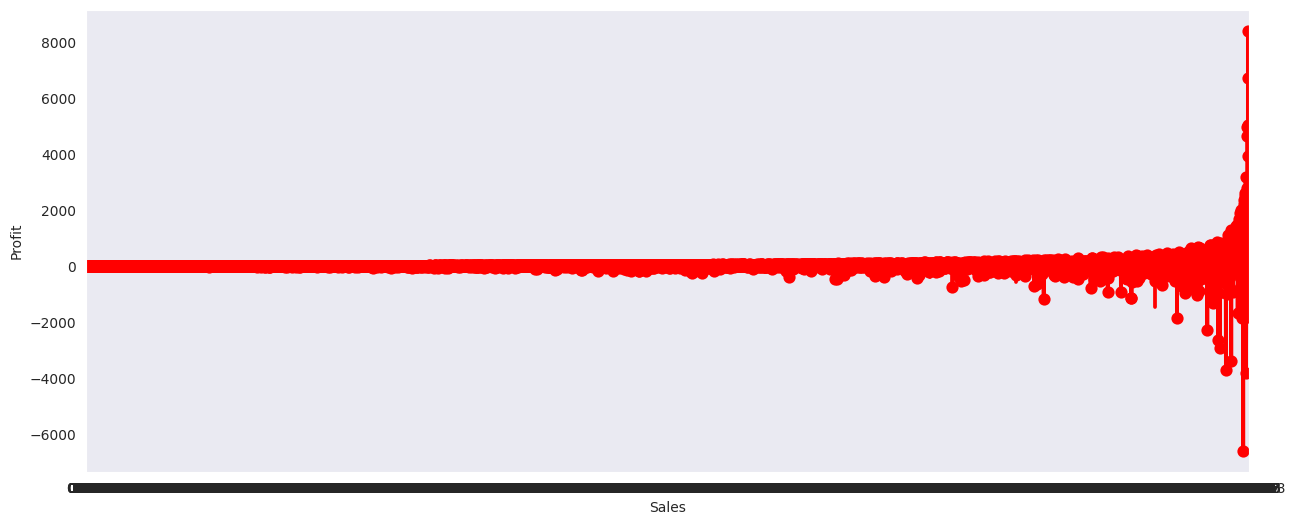

In [ ]:
plt.figure(figsize=(15,6))
sns.pointplot( x= 'Sales',y= 'Profit', data=store_df,color='Red')

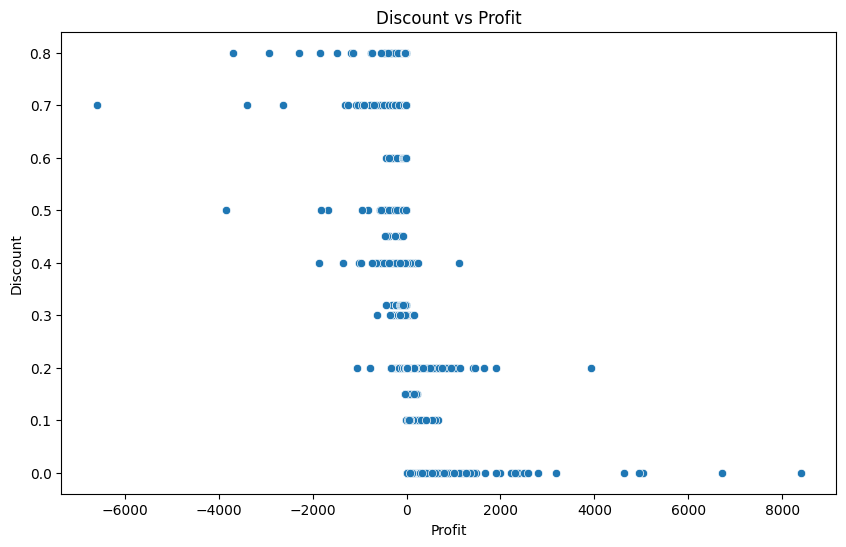

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Profit', y='Discount', data=store_df)
plt.title('Discount vs Profit')
plt.show()

##More magins of discounts, hinder the profit, where as minimal discount improves the profit

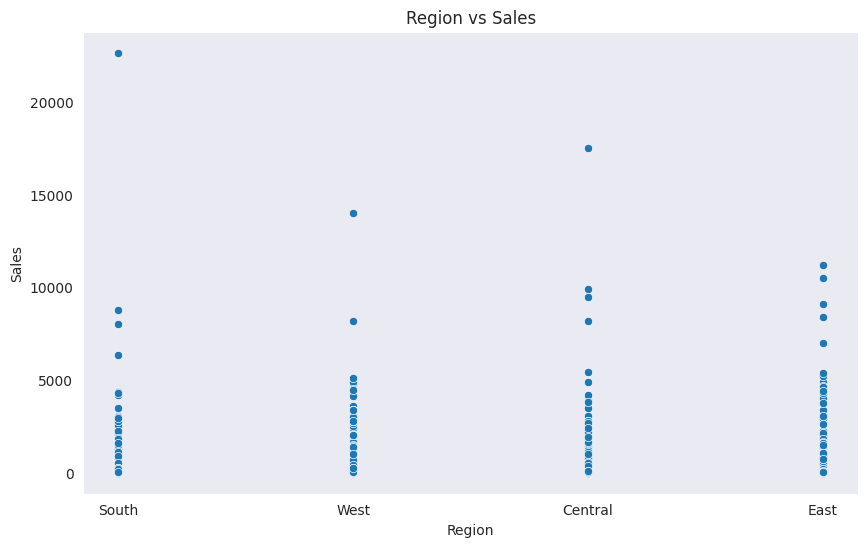

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x = "Region", y="Sales", data=store_df)
plt.title("Region vs Sales")
plt.show()

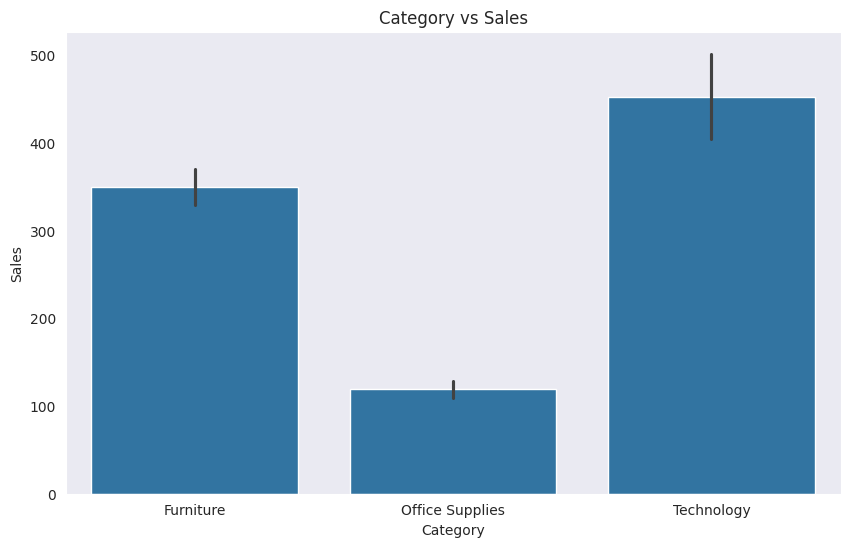

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x="Category", y="Sales", data=store_df)
plt.title("Category vs Sales")
plt.show()

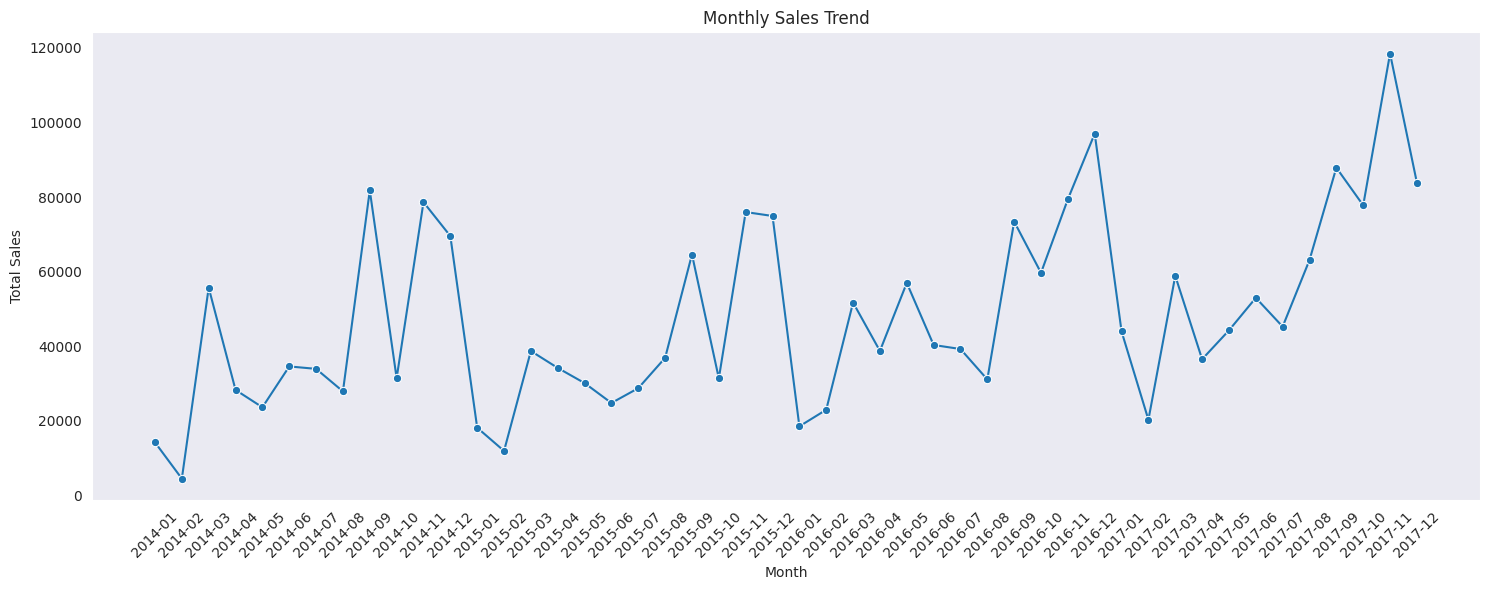

In [ ]:
store_df['Order Month'] = store_df['Order Date'].dt.to_period('M')

monthly_sales = store_df.groupby('Order Month')['Sales'].sum().reset_index()
monthly_sales['Order Month'] = monthly_sales['Order Month'].astype(str)
plt.figure(figsize=(15,6))
sns.lineplot(x='Order Month', y='Sales', data=monthly_sales, marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()


               Sales       Profit  Profit Margin %
Region                                            
West     725457.8245  108418.4489            14.94
East     678781.2400   91522.7800            13.48
South    391721.9050   46749.4303            11.93
Central  501239.8908   39706.3625             7.92


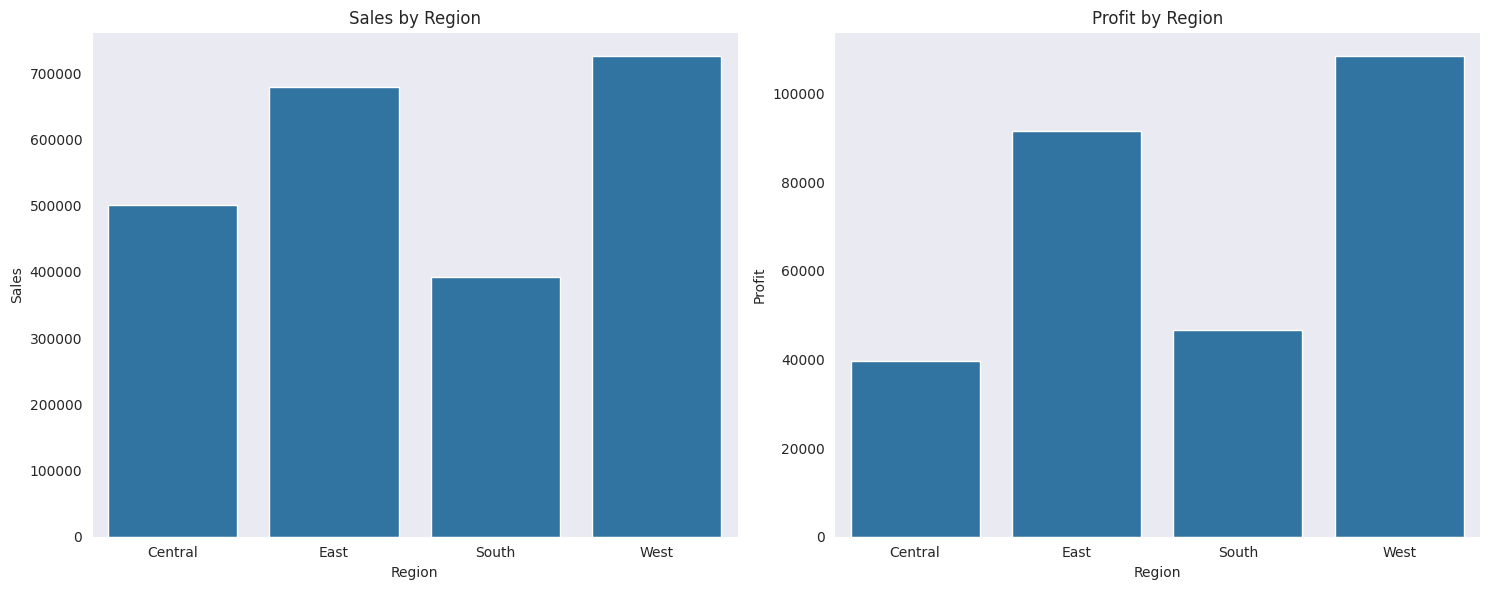

In [ ]:
region_summary = store_df.groupby('Region')[['Sales', 'Profit']].sum()
region_summary['Profit Margin %'] = (region_summary['Profit'] / region_summary['Sales'] * 100).round(2)
print(region_summary.sort_values('Profit Margin %', ascending=False))
fig, axes = plt.subplots(1, 2, figsize=(15,6))
sns.barplot(x=region_summary.index, y=region_summary['Sales'], ax=axes[0])
axes[0].set_title('Sales by Region')

sns.barplot(x=region_summary.index, y=region_summary['Profit'], ax=axes[1])
axes[1].set_title('Profit by Region')
plt.tight_layout()
plt.show()

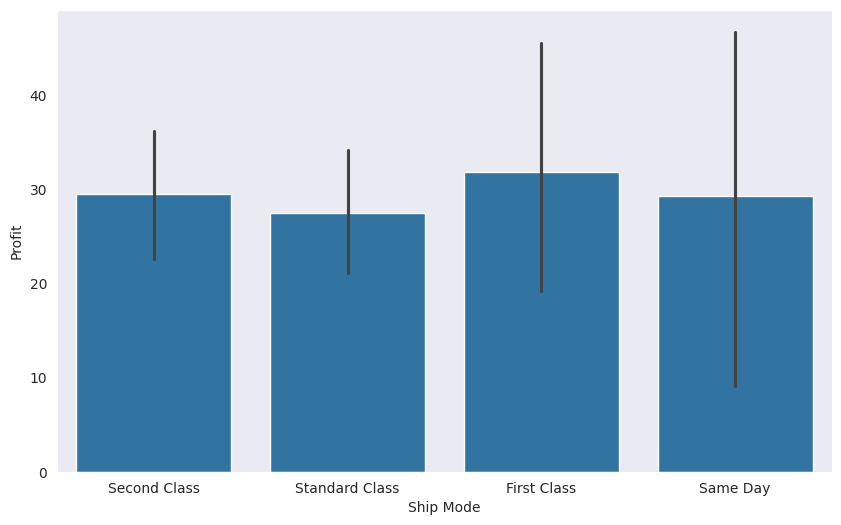

In [ ]:
plt.figure(figsize=(10,6))
ship_mode_profit = sns.barplot(x="Ship Mode", y="Profit",data=store_df)

<Axes: xlabel='Quantity', ylabel='Sales'>

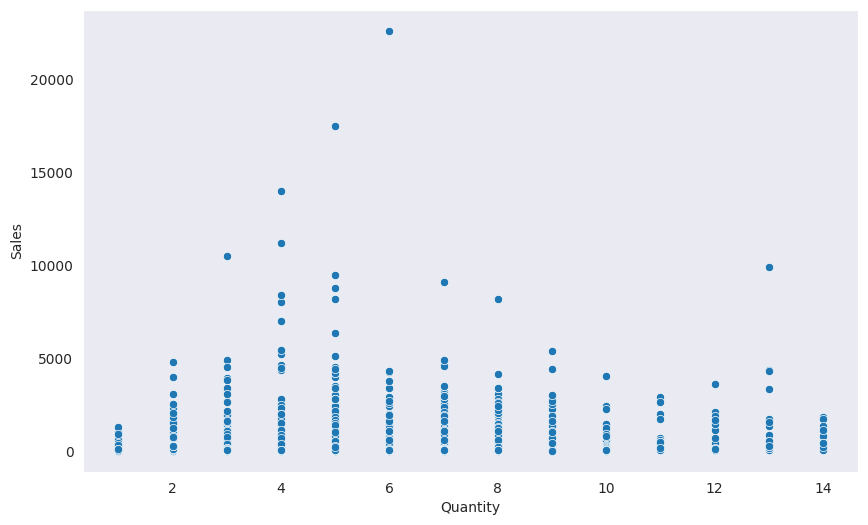

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="Quantity", y='Sales',data=store_df)

/tmp/ipykernel_1672/4272481721.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_summary = store_df.set_index('Order Date')[['Sales', 'Profit']].resample('M').sum()


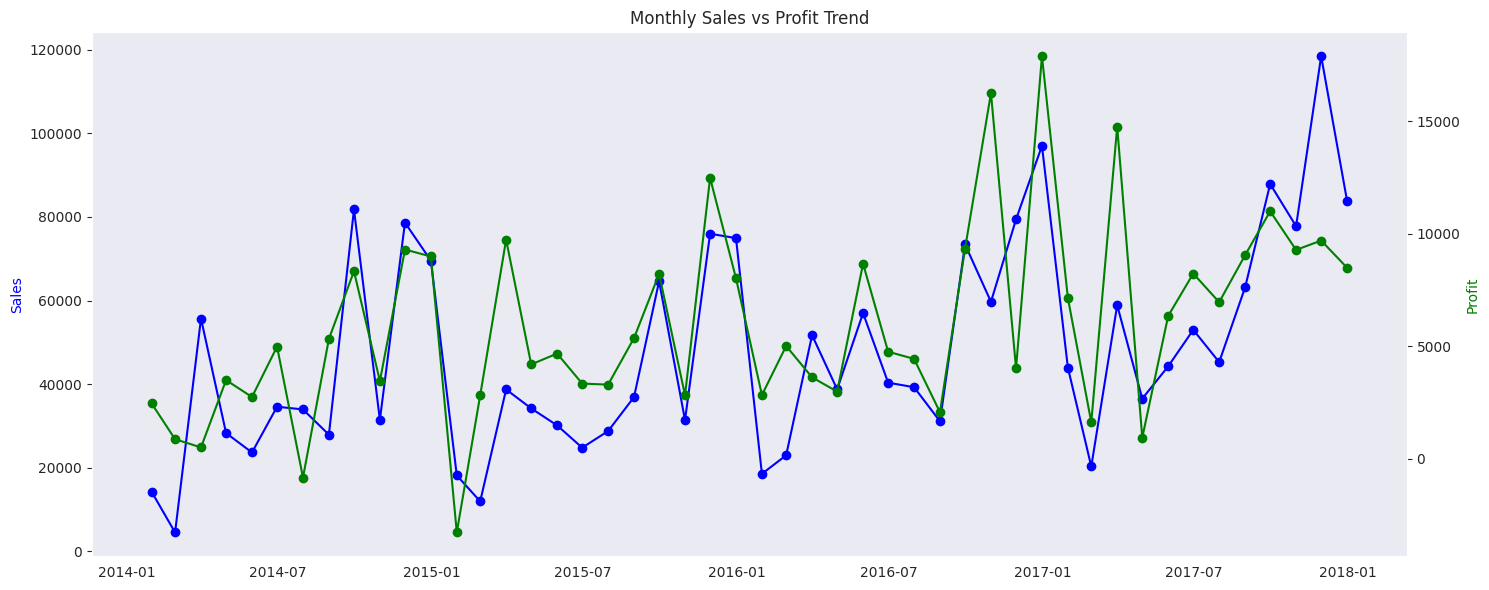

In [ ]:
monthly_summary = store_df.set_index('Order Date')[['Sales', 'Profit']].resample('M').sum()

fig, ax1 = plt.subplots(figsize=(15,6))

ax1.plot(monthly_summary.index, monthly_summary['Sales'], color='blue', marker='o', label='Sales')
ax1.set_ylabel('Sales', color='blue')

ax2 = ax1.twinx()
ax2.plot(monthly_summary.index, monthly_summary['Profit'], color='green', marker='o', label='Profit')
ax2.set_ylabel('Profit', color='green')

plt.title('Monthly Sales vs Profit Trend')
fig.tight_layout()
plt.show()

##step 3: feature engineering

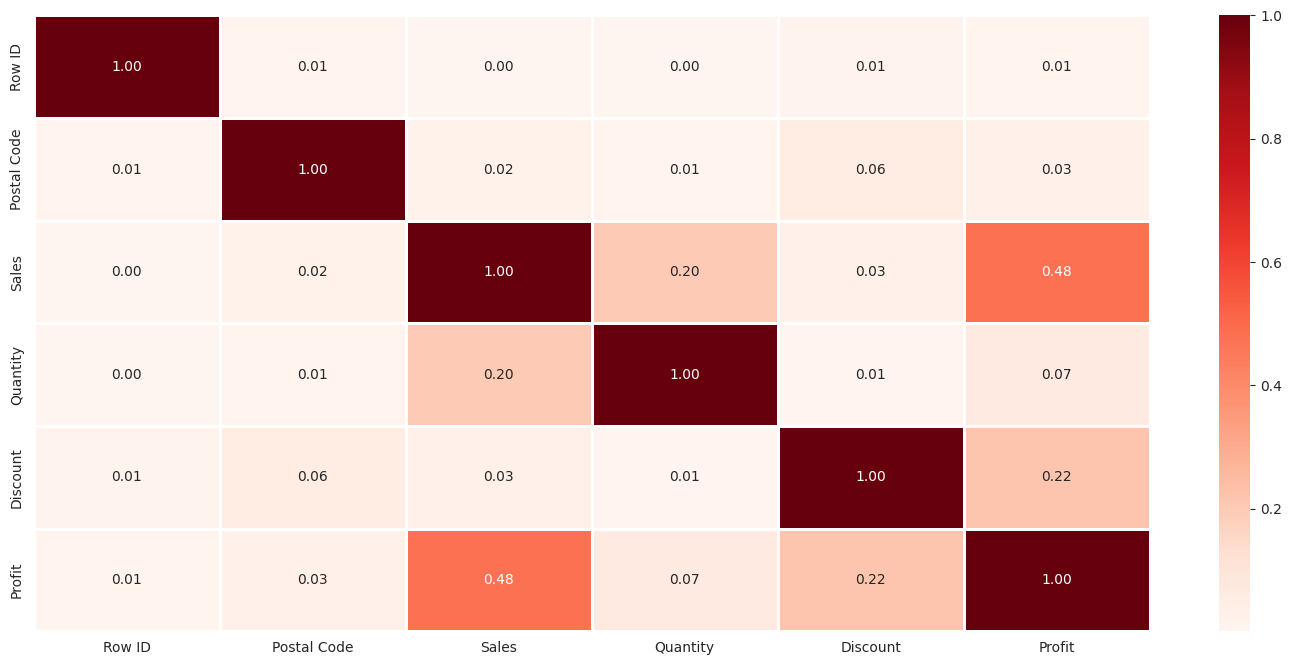

In [ ]:
plt.figure(figsize=(18,8))
correlation = store_df.corr(numeric_only=True)
sns.heatmap(abs(correlation), annot=True, cmap='Reds', linewidths=2, fmt=".2f")
plt.show()

##1.Date-based features (from Order Date / Ship Date)

import pandas as pd

# 1. Load
store_df = pd.read_csv('/content/sample_data/Superstore.csv', encoding='latin1')  # adjust path as needed

# 2. Convert dates
store_df['Order Date'] = pd.to_datetime(store_df['Order Date'])
store_df['Ship Date'] = pd.to_datetime(store_df['Ship Date'])

# 3. Feature engineering
store_df['Order Month'] = store_df['Order Date'].dt.month
store_df['Order Year'] = store_df['Order Date'].dt.year
store_df['Order Quarter'] = store_df['Order Date'].dt.quarter
store_df['Order Weekday'] = store_df['Order Date'].dt.day_name()
store_df['Order Day'] = store_df['Order Date'].dt.day
store_df['Shipping_Delay_Days'] = (store_df['Ship Date'] - store_df['Order Date']).dt.days

city_freq = store_df['City'].value_counts()
store_df['City_Frequency'] = store_df['City'].map(city_freq)

store_df['Discount_Bucket'] = pd.cut(store_df['Discount'],
                                        bins=[-0.01, 0, 0.2, 0.4, 1.0],
                                        labels=['No Discount', 'Low', 'Medium', 'High'])
store_df = pd.get_dummies(store_df, columns=['Discount_Bucket'], drop_first=True)

# 4. Set target BEFORE dropping columns from store_df
y = store_df['Sales']

# 5. Build X - drop identifiers, leakage, raw dates, redundant location cols
X = store_df.drop(columns=[
    'Row ID', 'Order ID', 'Customer ID', 'Customer Name',
    'Product ID', 'Product Name', 'Country',
    'Order Date', 'Ship Date', 'City', 'Postal Code',
    'Sales', 'Profit'
])

# 6. One-Hot Encode remaining categoricals
X = pd.get_dummies(X, columns=['Ship Mode', 'Segment', 'State', 'Region',
                                  'Category', 'Sub-Category', 'Order Weekday'],
                     drop_first=True)

# 7. Verify
print(X.dtypes.value_counts())
print(X.select_dtypes(include='object').columns.tolist())
print(X.shape)

In [ ]:
store_df['Order Month'] = store_df['Order Date'].dt.month
store_df['Order Year'] = store_df['Order Date'].dt.year
store_df['Order Quarter'] = store_df['Order Date'].dt.quarter
store_df['Order Weekday'] = store_df['Order Date'].dt.day_name()
store_df['Order Day'] = store_df['Order Date'].dt.day
print(store_df['Order Year'])

0       2016
1       2016
2       2016
3       2015
4       2015
        ... 
9989    2014
9990    2017
9991    2017
9992    2017
9993    2017
Name: Order Year, Length: 9994, dtype: int32


##2. Shipping Delay

In [ ]:
store_df['Shipping_Delay_Days'] = (store_df['Ship Date'] - store_df['Order Date']).dt.days
print(store_df['Shipping_Delay_Days'])

0       3
1       3
2       4
3       7
4       7
       ..
9989    2
9990    5
9991    5
9992    5
9993    5
Name: Shipping_Delay_Days, Length: 9994, dtype: int64


##3.Encode categorical values

In [ ]:
store_df = pd.get_dummies(store_df, columns=['Segment', 'Region', 'Ship Mode', 'Category'], drop_first=True)

In [ ]:
print(store_df['Sub-Category'].nunique())
print(store_df['State'].nunique())
print(store_df['City'].nunique())

17
49
531


##4. Frequency encoding

In [ ]:
city_freq = store_df['City'].value_counts()
store_df['City_Frequency'] = store_df['City'].map(city_freq)
print(store_df['City_Frequency'])

0        51
1        51
2       747
3        15
4        15
       ... 
9989     57
9990     11
9991     11
9992     11
9993     17
Name: City_Frequency, Length: 9994, dtype: int64


##6. Create a "Discount Bucket" feature

In [ ]:
store_df['Discount_Bucket'] = pd.cut(store_df['Discount'],
                                        bins=[-0.01, 0, 0.2, 0.4, 1.0],
                                        labels=['No Discount', 'Low', 'Medium', 'High'])
store_df = pd.get_dummies(store_df, columns=['Discount_Bucket'], drop_first=True)
print(store_df)

     Order Date  Ship Date       Ship Mode    Segment             City  \
0    2016-11-08 2016-11-11    Second Class   Consumer        Henderson   
1    2016-11-08 2016-11-11    Second Class   Consumer        Henderson   
2    2016-06-12 2016-06-16    Second Class  Corporate      Los Angeles   
3    2015-10-11 2015-10-18  Standard Class   Consumer  Fort Lauderdale   
4    2015-10-11 2015-10-18  Standard Class   Consumer  Fort Lauderdale   
...         ...        ...             ...        ...              ...   
9989 2014-01-21 2014-01-23    Second Class   Consumer            Miami   
9990 2017-02-26 2017-03-03  Standard Class   Consumer       Costa Mesa   
9991 2017-02-26 2017-03-03  Standard Class   Consumer       Costa Mesa   
9992 2017-02-26 2017-03-03  Standard Class   Consumer       Costa Mesa   
9993 2017-05-04 2017-05-09    Second Class   Consumer      Westminster   

           State  Postal Code Region         Category Sub-Category  ...  \
0       Kentucky        42420  South

##8. Scale numeric values

In [ ]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['Quantity', 'Discount', 'Shipping_Delay_Days']  # exclude target
scaler = StandardScaler()
store_df[numeric_cols] = scaler.fit_transform(store_df[numeric_cols])

##Step 4: Train/Test split

In [ ]:
# Target variable — what you're predicting
y = store_df['Sales']

# Features — everything else (drop target and any leakage-risk columns)
X = store_df.drop(columns=['Sales'])
print(X.dtypes)

Row ID                             int64
Order ID                          object
Order Date                datetime64[ns]
Ship Date                 datetime64[ns]
Ship Mode                         object
Customer ID                       object
Customer Name                     object
Segment                           object
Country                           object
City                              object
State                             object
Postal Code                        int64
Region                            object
Product ID                        object
Category                          object
Sub-Category                      object
Product Name                      object
Quantity                           int64
Discount                         float64
Profit                           float64
Order Month                        int32
Order Year                         int32
Order Quarter                      int32
Order Weekday                     object
Order Day       

In [ ]:
print(store_df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Order Month', 'Order Year', 'Order Quarter', 'Order Weekday', 'Order Day', 'Shipping_Delay_Days', 'City_Frequency', 'Discount_Bucket_Low', 'Discount_Bucket_Medium', 'Discount_Bucket_High']


In [ ]:
# Check for duplicate column names

store_df = store_df.loc[:, ~store_df.columns.duplicated()]
print(store_df.columns[store_df.columns.duplicated()])

Index([], dtype='object')


In [ ]:
print(store_df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [ ]:
print(store_df.columns.tolist())

['Order Date', 'Ship Date', 'Ship Mode', 'Segment', 'City', 'State', 'Postal Code', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit', 'Order Month', 'Order Year', 'Order Quarter', 'Order Weekday', 'Order Day', 'Shipping_Delay_Days', 'City_Frequency', 'Discount_Bucket_Low', 'Discount_Bucket_Medium', 'Discount_Bucket_High']


In [ ]:
X = X.drop(columns=['Profit'])

KeyError: "['Profit'] not found in axis"

In [ ]:
X = X.drop(columns=['Order Date', 'Ship Date'])

In [ ]:
X = pd.get_dummies(X, columns=['Ship Mode', 'Segment', 'State', 'Region',
                                  'Category', 'Sub-Category'],
                     drop_first=True)

KeyError: "None of [Index(['Ship Mode', 'Segment', 'State', 'Region', 'Category', 'Sub-Category'], dtype='object')] are in the [columns]"

In [ ]:

print(X.select_dtypes(include='object').columns.tolist())

['Order ID', 'Customer ID', 'Customer Name', 'Country', 'City', 'Product ID', 'Product Name', 'Order Weekday']


In [ ]:
# Convert boolean discount bucket columns to int
bucket_cols = ['Discount_Bucket_Low', 'Discount_Bucket_Medium', 'Discount_Bucket_High']
X[bucket_cols] = X[bucket_cols].astype(int)


In [ ]:
print(X.dtypes.value_counts())
print(X.shape)

bool              74
int64              8
object             8
int32              4
datetime64[ns]     2
float64            1
Name: count, dtype: int64
(9994, 97)


In [ ]:
# Confirm X is clean
print("Object columns in X:", X.select_dtypes(include='object').columns.tolist())

# Re-split (X is clean now, but X_train/X_test are still the OLD stale split)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Success. X_train_scaled shape:", X_train_scaled.shape)

Object columns in X: []
Success. X_train_scaled shape: (7995, 93)


In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (7995, 97)
X_test shape: (1999, 97)
y_train shape: (7995,)
y_test shape: (1999,)


## train linear regression

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled,y_train)
lr_preds = lr.predict(X_test_scaled)

## Train Ridge Regression

In [ ]:
ridge= Ridge(alpha = 1.0)
ridge.fit(X_train_scaled, y_train)
ridge_preds = ridge.predict(X_test_scaled)

## Evaluating both models

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} -> RMSE: {rmse:.2f}, R²: {r2:.4f}")

evaluate(y_test, lr_preds, "Linear Regression")
evaluate(y_test, ridge_preds, "Ridge Regression")

Linear Regression -> RMSE: 695.59, R²: 0.1809
Ridge Regression -> RMSE: 695.58, R²: 0.1809


 ## Try a few Ridge alpha values (basic tuning)

In [ ]:
for alpha in [200, 500, 1000, 5000]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    preds = ridge.predict(X_test_scaled)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"alpha={alpha} -> RMSE: {rmse:.2f}, R²: {r2:.4f}")

# from sklearn.ensemble import RandomForestRegressor

# rf = RandomForestRegressor(n_estimators=100, random_state=42)
# rf.fit(X_train, y_train)  # tree models don't need scaling
# rf_preds = rf.predict(X_test)

# evaluate(y_test, rf_preds, "Random Forest")

alpha=200 -> RMSE: 695.19, R²: 0.1818
alpha=500 -> RMSE: 695.96, R²: 0.1800
alpha=1000 -> RMSE: 697.47, R²: 0.1765
alpha=5000 -> RMSE: 708.95, R²: 0.1491


### Visualizing predictions vs actual (sanity check)

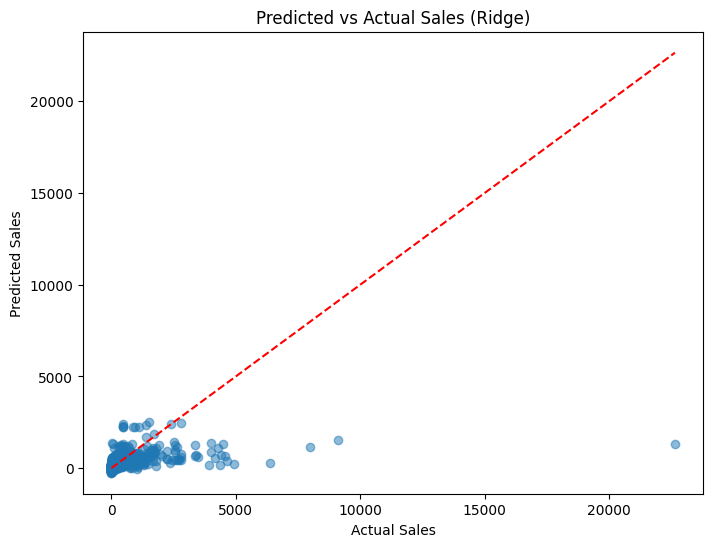

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, ridge_preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Predicted vs Actual Sales (Ridge)')
plt.show()